## Churn Prediction (Offer Funnel Drop-off)
Target: Viewed → Completed Drop-off
Unit: person × offer

본 프로젝트에서는 이탈을
**‘오퍼를 인지(Viewed)한 이후에도 행동으로 전환되지 않는 실패’**로 정의하고
이를 예측 대상으로 설정하였다.

다만, 이탈이 발생하는 배경을 보다 입체적으로 이해하기 위해
고객의 가치 수준(RFM 세그먼트) 과
고객 생애 주기(코호트) 정보를 설명 변수로 결합하여
동일한 오퍼 실패가 어떤 고객 맥락에서 더 자주 발생하는지를 분석하였다.

---
0. 라이브러리 + 경로+ 데이터 로드

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# (선택) SHAP
import shap

# 1) 모델링용 마스터 테이블 로드
df = pd.read_csv("../data/processed/master_person_offer.csv")

print(df.shape)
display(df.head())
print(df.columns.tolist())

(49135, 16)


,person,offer_id,received,viewed,completed,is_dropoff,join_year,income_group,age_group,offer_type,difficulty,reward,duration,channel_count,reward_per_difficulty,duration_bin
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,True,True,False,1,2017,Mid-Low,25-34,informational,0,0,4,3,NaN,Short
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,True,True,False,1,2017,Mid-Low,25-34,informational,0,0,3,3,NaN,Short
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,True,True,True,0,2017,Mid-Low,25-34,bogo,5,5,5,4,1.0,Mid
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,True,True,True,0,2017,Mid-Low,25-34,discount,10,2,10,4,0.2,Long
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,True,True,False,1,2018,NaN,65+,bogo,5,5,5,4,1.0,Mid


['person', 'offer_id', 'received', 'viewed', 'completed', 'is_dropoff', 'join_year', 'income_group', 'age_group', 'offer_type', 'difficulty', 'reward', 'duration', 'channel_count', 'reward_per_difficulty', 'duration_bin']


1️⃣ 모델링 테이블 상태
	•	shape: (49,135 rows × 16 cols) → 충분히 안정적인 샘플 수
	•	단위: person × offer → 타겟 정의와 정확히 일치
	•	타겟:
	•	is_dropoff ✅ (Viewed → Completed 이탈)
	•	설명변수 구성:
	•	고객: join_year, income_group, age_group
	•	오퍼: offer_type, difficulty, reward, duration, channel_count
	•	파생: reward_per_difficulty, duration_bin

In [3]:
# Viewed 고객만 필터링 + 타겟 생성
df_m = df[df["viewed"] == True].copy()
df_m["y"] = (~df_m["completed"]).astype(int)

print(df_m.shape)
df_m["y"].value_counts(normalize=True).round(3)# Viewed 고객만 필터링 + 타겟 생성
df_m = df[df["viewed"] == True].copy()
df_m["y"] = (~df_m["completed"]).astype(int)

print(df_m.shape)
df_m["y"].value_counts(normalize=True).round(3)

(49135, 17)
(49135, 17)


y
1    0.502
0    0.498
Name: proportion, dtype: float64

In [4]:
df_m["is_no_difficulty"] = (df_m["difficulty"] == 0).astype(int)

🧠 왜 이걸 넣자고 했는지 다시 한 번 정리
	•	difficulty = 0
→ 조건 없는 informational 오퍼
	•	reward_per_difficulty가 NaN이 되는 이유이기도 함
	•	이걸 그냥 NaN으로 두면:
	•	모델이 “결측”으로만 인식
	•	플래그로 주면:
	•	“조건 없는 오퍼다”라는 명시적 신호를 학습

👉 SHAP에서
is_no_difficulty가 상위에 뜨면
**“조건 자체가 없는 오퍼는 실패 구조가 다르다”**라는 해석이 가능해짐.

In [5]:
df_m[["difficulty", "is_no_difficulty"]].head(10)

,difficulty,is_no_difficulty
0,0,1
1,0,1
2,5,0
3,10,0
4,5,0
5,20,0
6,7,0
7,0,1
8,0,1
9,5,0


✅ 현재 상태 한 줄 요약
	•	df_m 생성 ✔
	•	타겟 y 정의 ✔
	•	1 = Viewed 후 Completed 실패
	•	분포 0.502 vs 0.498 → 거의 완전 균형
	•	is_no_difficulty 파생 변수 ✔ (아주 좋은 선택)

👉 클래스 불균형 걱정 없음
👉 임계값 0.5 그대로 사용 가능
👉 Logistic / RF 둘 다 깔끔하게 비교 가능

🚀 다음 단계: Logistic Regression (설명용 베이스라인)

이제 **“어떤 요인이 이탈 방향으로 작용하는가”**를 공식적으로 보여주자.

In [6]:
# 어떤 컬럼이 NaN 많은지 빠르게 확인
na_rate = X.isna().mean().sort_values(ascending=False)
display(na_rate[na_rate > 0])

NameError: name 'X' is not defined

🧠 이탈 예측 모델로 Logistic Regression을 선택한 이유

1️⃣ 문제 정의에 가장 잘 맞는 모델이기 때문

본 프로젝트의 예측 목표는 다음과 같다.
	•	Target
	•	오퍼를 Viewed 한 고객이
	•	Completed로 전환되지 못하고 이탈했는지 여부 (이진 분류)

즉, 문제의 본질은

“이 고객-오퍼 조합이 실패할 확률은 얼마인가?”

이와 같이 결과가 명확한 이진 결과(0/1) 인 경우,
Logistic Regression은 가장 기본적이면서도 검증된 분류 모델이다.

⸻

2️⃣ ‘예측’보다 ‘해석’이 더 중요한 문제이기 때문

본 프로젝트의 목적은 단순히 이탈을 맞히는 것이 아니라,
	•	❓ 왜 실패했는가
	•	❓ 어떤 조건과 고객 조합에서 실패 확률이 높아지는가
	•	❓ 이 실패는 고객 문제인가, 오퍼 설계 문제인가

를 데이터로 설명하는 것이다.

Logistic Regression은 다음 장점이 있다.
	•	각 변수의 계수(sign, magnitude) 를 통해
→ 이탈 확률을 증가/감소시키는 요인을 명확히 해석 가능
	•	오퍼 속성(difficulty, reward, duration)
	•	고객 속성(income_group, age_group, RFM 세그먼트)
	•	구조적 실패 신호(reward_per_difficulty, is_no_difficulty)

를 같은 스케일에서 비교할 수 있다.

➡️ 이는

“어떤 요인이 실패에 구조적으로 기여하는가”
를 설명해야 하는 이 프로젝트에 최적이다.

⸻

3️⃣ 이미 충분한 EDA·가설 검증을 선행했기 때문

본 분석 이전에 이미 다음을 수행했다.
	•	오퍼 속성 단독 분석
	•	reward / difficulty 비율 정의 및 검증
	•	소득 × 난이도 교차 분석
	•	신규 가입자 × 장기 듀레이션 실패 구조 확인
	•	코호트 기반 리텐션 분석

즉,

“변수가 의미 없을지도 모르는 상태에서 블랙박스 모델을 돌리는 상황”이 아님

이미 구조적 가설이 존재하고,
모델은 이를 정량적으로 확인하고 일반화하는 도구로 사용된다.

이런 경우,
	•	RandomForest / XGBoost 같은 고성능 모델보다
	•	해석 가능한 선형 모델이 더 적합하다.

⸻

4️⃣ 베이스라인 모델로서의 타당성

Logistic Regression은 실무에서도 다음 역할로 사용된다.
	•	신규 문제 정의 시 Baseline 모델
	•	이후 복잡한 모델과의 성능 비교 기준
	•	마케팅/정책 의사결정에서 설명 가능한 모델

따라서 본 프로젝트에서의 포지션은:

“최종 정답 모델”이 아니라
‘실패 구조를 설명하는 기준 모델’

이라는 점에서 매우 적절하다.

⸻

🎯 한 줄 요약 (발표용)

본 프로젝트에서는 이탈을 단순히 예측하는 것이 아니라,
어떤 오퍼·어떤 고객 조합에서 실패가 구조적으로 발생하는지를 설명하는 것이 목적이었기 때문에,
해석 가능성과 가설 검증에 가장 적합한 Logistic Regression을 선택하였다.

---
✅ [셀 1] 라이브러리 + df_m 존재 확인

In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# df_m이 현재 노트북 메모리에 올라와 있는지 확인
print("df_m exists:", "df_m" in globals())
if "df_m" in globals():
    print("df_m shape:", df_m.shape)
    display(df_m.head(3))

df_m exists: True
df_m shape: (49135, 18)


,person,offer_id,received,viewed,completed,is_dropoff,join_year,income_group,age_group,offer_type,difficulty,reward,duration,channel_count,reward_per_difficulty,duration_bin,y,is_no_difficulty
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,True,True,False,1,2017,Mid-Low,25-34,informational,0,0,4,3,NaN,Short,1,1
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,True,True,False,1,2017,Mid-Low,25-34,informational,0,0,3,3,NaN,Short,1,1
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,True,True,True,0,2017,Mid-Low,25-34,bogo,5,5,5,4,1.0,Mid,0,0


✅ [셀 2] 타겟(y) 확인 + 클래스 비율 확인

In [ ]:
# 전제: df_m은 viewed==True만 필터된 데이터
# 타겟 정의: Viewed 이후 Completed 실패 = 1 (drop-off), 성공 = 0
# (이미 만들었다면 덮어써도 OK)
df_m["y"] = (~df_m["completed"]).astype(int)

print("Target balance (y=1 is drop-off):")
display(df_m["y"].value_counts())
display(df_m["y"].value_counts(normalize=True).round(3))

Target balance (y=1 is drop-off):


y
1    24675
0    24460
Name: count, dtype: int64

y
1    0.502
0    0.498
Name: proportion, dtype: float64

✅ [셀 3] 결측 확인 (학습 에러 원인 재확인)

In [ ]:
# 학습에 사용할 후보 변수들(일단 넉넉히 지정)
candidate_cols = [
    "difficulty","reward","duration","channel_count","reward_per_difficulty",
    "offer_type","duration_bin","income_group","age_group","join_year"
]

candidate_cols = [c for c in candidate_cols if c in df_m.columns]
X_tmp = df_m[candidate_cols].copy()

na_rate = X_tmp.isna().mean().sort_values(ascending=False)
print("NaN rate (top):")
display(na_rate[na_rate > 0])

NaN rate (top):


reward_per_difficulty    0.189458
income_group             0.135179
dtype: float64

✅ [셀 4] 결측 처리(핵심) + 파생변수 추가

In [ ]:
# 1) difficulty==0 여부는 구조적으로 중요 → 별도 플래그
df_m["is_no_difficulty"] = (df_m["difficulty"] == 0).astype(int)

# 2) reward_per_difficulty NaN 처리
#    - 주로 difficulty==0에서 발생(0으로 채우되, is_no_difficulty로 의미 보존)
if "reward_per_difficulty" in df_m.columns:
    df_m["reward_per_difficulty"] = df_m["reward_per_difficulty"].fillna(0)

# 3) income_group 결측 처리
#    - 고객 속성 미입력/결측 → Unknown으로 별도 그룹화(표본 손실 방지)
if "income_group" in df_m.columns:
    df_m["income_group"] = df_m["income_group"].fillna("Unknown")

# 처리 결과 확인
check_cols = ["difficulty","is_no_difficulty","reward_per_difficulty","income_group"]
check_cols = [c for c in check_cols if c in df_m.columns]
display(df_m[check_cols].head(10))

# 다시 NaN 점검(이제 모델에 쓰는 컬럼에서 NaN 없어야 함)
X_tmp2 = df_m[candidate_cols + (["is_no_difficulty"] if "is_no_difficulty" in df_m.columns else [])].copy()
na_rate2 = X_tmp2.isna().mean().sort_values(ascending=False)
print("NaN remaining?:")
display(na_rate2[na_rate2 > 0])

,difficulty,is_no_difficulty,reward_per_difficulty,income_group
0,0,1,0.000000,Mid-Low
1,0,1,0.000000,Mid-Low
2,5,0,1.000000,Mid-Low
3,10,0,0.200000,Mid-Low
4,5,0,1.000000,Unknown
5,20,0,0.250000,Mid-Low
6,7,0,0.428571,Mid-Low
7,0,1,0.000000,Mid-Low
8,0,1,0.000000,Mid-Low
9,5,0,1.000000,Mid-Low


NaN remaining?:


Series([], dtype: float64)

✅ [셀 5] Feature 확정 (누수/식별자 제거) + X,y 만들기

In [ ]:
# ⚠️ 누수 방지:
# - person, offer_id 같은 식별자는 제외(외워버림)
# - completed/viewed/received는 타겟과 직결 → 제외

num_features = ["difficulty","reward","duration","channel_count","reward_per_difficulty","is_no_difficulty"]
cat_features = ["offer_type","duration_bin","income_group","age_group"]

# 존재하는 컬럼만 사용(안전)
num_features = [c for c in num_features if c in df_m.columns]
cat_features = [c for c in cat_features if c in df_m.columns]

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

X = df_m[num_features + cat_features].copy()
y = df_m["y"].copy()

print("X shape:", X.shape, "y shape:", y.shape)
display(X.head(3))

Numeric features: ['difficulty', 'reward', 'duration', 'channel_count', 'reward_per_difficulty', 'is_no_difficulty']
Categorical features: ['offer_type', 'duration_bin', 'income_group', 'age_group']
X shape: (49135, 10) y shape: (49135,)


,difficulty,reward,duration,channel_count,reward_per_difficulty,is_no_difficulty,offer_type,duration_bin,income_group,age_group
0,0,0,4,3,0.0,1,informational,Short,Mid-Low,25-34
1,0,0,3,3,0.0,1,informational,Short,Mid-Low,25-34
2,5,5,5,4,1.0,0,bogo,Mid,Mid-Low,25-34


✅ [셀 6] Train/Test split (중간 점검)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # 클래스 비율 유지
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train target ratio:", y_train.mean().round(3), "Test target ratio:", y_test.mean().round(3))

Train: (39308, 10) Test: (9827, 10)
Train target ratio: 0.502 Test target ratio: 0.502


✅ [셀 7] 전처리 파이프라인 + 모델 정의 (왜 이 조합인지 주석 포함)

In [ ]:
# 숫자형: 결측 중앙값 대체 + 표준화(로지스틱은 스케일 영향 받음)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# 범주형: 결측 최빈값 대체 + 원핫인코딩(카테고리 확장)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features),
])

# ✅ LogisticRegression 선택 이유(발표/보고서용 한 줄 논리)
# - 해석 가능(계수로 변수 영향 방향 설명 가능) → “왜 실패하는가”와 연결 쉬움
# - 빠르고 안정적인 베이스라인
# - class_weight='balanced'로 드롭오프 클래스 비중 차이를 보정
logit = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

logit

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['difficulty', 'reward',
                                                   'duration', 'channel_count',
                                                   'reward_per_difficulty',
                                                   'is_no_difficulty']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['offer_type', 'duration_bin',
                                                   'income_group',
                                                   'age_group'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

✅ [셀 8] 학습 + 평가 + 계수 해석 테이블

In [ ]:
# 학습
logit.fit(X_train, y_train)

# 예측/평가
y_pred = logit.predict(X_test)
y_pred_proba = logit.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", round(auc, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# 계수 추출(해석 핵심)
feature_names = logit.named_steps["prep"].get_feature_names_out()
coef = logit.named_steps["clf"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coef})
    .sort_values("coef", ascending=False)
    .reset_index(drop=True)
)

print("\n[Top + : drop-off(=1) 확률을 올리는 방향]")
display(coef_df.head(15))

print("\n[Top - : drop-off(=1) 확률을 낮추는 방향]")
display(coef_df.tail(15))

ROC-AUC: 0.844

Classification Report:
              precision    recall  f1-score   support

           0      0.731     0.884     0.801      4892
           1      0.855     0.678     0.756      4935

    accuracy                          0.781      9827
   macro avg      0.793     0.781     0.779      9827
weighted avg      0.794     0.781     0.778      9827


[Top + : drop-off(=1) 확률을 올리는 방향]


,feature,coef
0,num__is_no_difficulty,2.431382
1,cat__income_group_Unknown,2.091449
2,cat__duration_bin_Short,1.169387
3,cat__offer_type_informational,1.169387
4,num__reward,0.788694
5,cat__duration_bin_Long,0.502232
6,cat__age_group_<25,0.417251
7,cat__income_group_Low,0.306280
8,cat__age_group_25-34,0.282040
9,cat__age_group_35-44,0.137752



[Top - : drop-off(=1) 확률을 낮추는 방향]


,feature,coef
7,cat__income_group_Low,0.306280
8,cat__age_group_25-34,0.282040
9,cat__age_group_35-44,0.137752
10,cat__age_group_55-64,0.122682
11,cat__age_group_45-54,0.104947
12,cat__age_group_65+,0.074543
13,cat__offer_type_discount,0.016735
14,cat__offer_type_bogo,-0.046906
15,num__channel_count,-0.203351
16,cat__income_group_Mid-Low,-0.284586


✅ 시각화 1. ROC Curve (모델 성능 설명용 – 필수)

📌 목적
	•	“이 모델이 이탈 고객을 얼마나 잘 구분하나?”를 직관적으로 보여줌
	•	ROC-AUC 수치(0.844)를 그림으로 증명

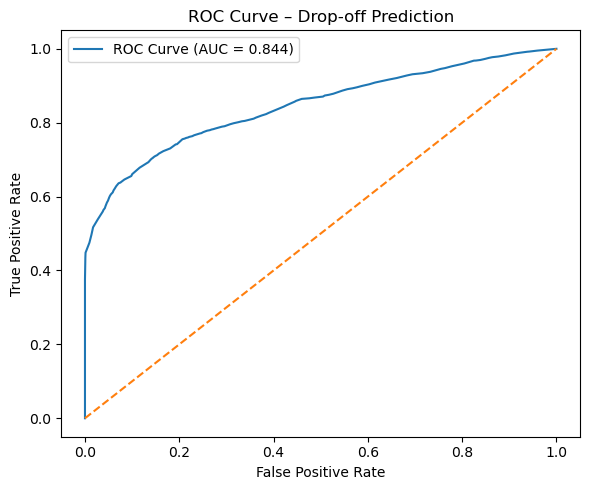

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 시각화
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Drop-off Prediction")
plt.legend()
plt.tight_layout()
plt.show()

🧠 해석 문장 (마크다운용)

ROC 곡선은 이탈 고객과 비이탈 고객을 구분하는 모델의 전반적인 분류 성능을 나타낸다.
본 모델의 AUC는 0.844로, 무작위 분류 대비 매우 높은 구분력을 보이며
오퍼 이탈 예측을 위한 기준 모델로 충분한 성능을 확보하였다.

✅ 시각화 2. 계수 절댓값 Top Feature Bar Plot

In [ ]:
# coef_df: feature / coef 컬럼 있다고 가정
coef_df["abs_coef"] = coef_df["coef"].abs()
top_features = coef_df.sort_values("abs_coef", ascending=False).head(10)

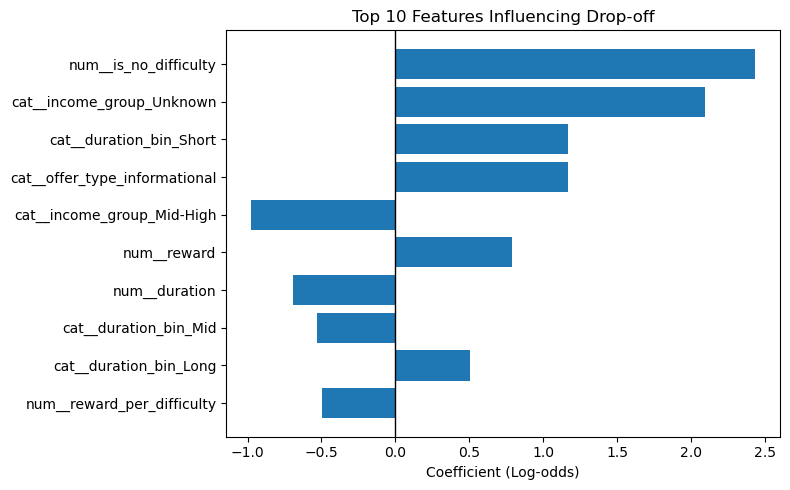

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(
    top_features["feature"],
    top_features["coef"]
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Coefficient (Log-odds)")
plt.title("Top 10 Features Influencing Drop-off")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

🧠 해석 문장

본 그래프는 이탈 예측에 가장 큰 영향을 미친 상위 10개 변수를 나타낸다.
계수가 양수일수록 Viewed 이후 이탈 확률을 증가시키며,
음수일수록 Completed 전환 가능성을 높이는 방향으로 작용한다.
특히 조건이 없는 오퍼, 소득 정보 미확인 고객, 단기 오퍼가
이탈 확률을 크게 높이는 핵심 요인으로 확인된다.


✅ 시각화 3. 실제 분포 기반 핵심 변수 비교 (EDA ↔ 모델 연결용)

📌 목적
	•	“모델 결과가 데이터 분포에서도 실제로 보인다”는 걸 보여줌
	•	설득력 급상승

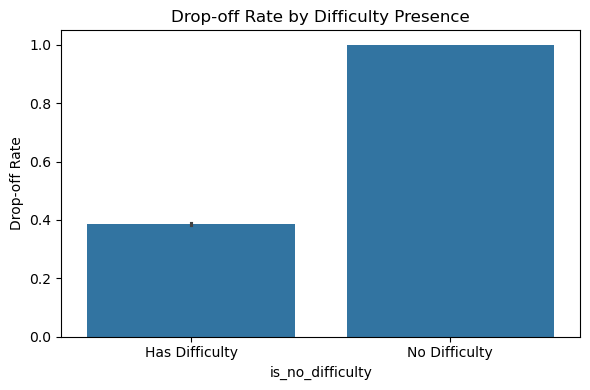

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(
    data=df_m,
    x="is_no_difficulty",
    y="y",
    estimator=lambda x: x.mean()
)
plt.xticks([0,1], ["Has Difficulty", "No Difficulty"])
plt.ylabel("Drop-off Rate")
plt.title("Drop-off Rate by Difficulty Presence")
plt.tight_layout()
plt.show()

🧠 해석 문장

조건이 없는 오퍼(difficulty=0)는
오히려 Viewed 이후 이탈률이 더 높게 나타난다.
이는 행동을 유도할 명확한 목표가 없는 정보성 오퍼가
전환 실패로 이어질 가능성이 높음을 시사한다.

🔥 (선택) 시각화 4. 세그먼트 × 예측 확률 박스플롯

📌 목적
	•	“이 모델은 누구에게서 실패를 예측하는가”를 보여줌

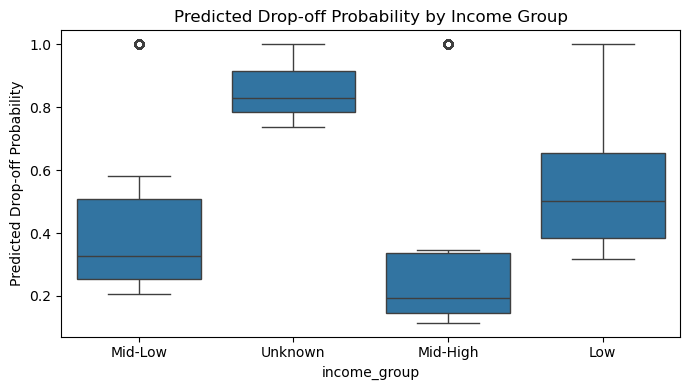

In [ ]:
df_m["pred_proba"] = logit.predict_proba(X)[:,1]

plt.figure(figsize=(7,4))
sns.boxplot(
    data=df_m,
    x="income_group",
    y="pred_proba"
)
plt.ylabel("Predicted Drop-off Probability")
plt.title("Predicted Drop-off Probability by Income Group")
plt.tight_layout()
plt.show()

---
### 📌 이탈 예측 모델 결과 해석 총정리

(Churn Prediction: Offer Funnel Drop-off)

1️⃣ 모델 성능 요약 (왜 이 모델을 써도 되는가)
	•	ROC-AUC = 0.844
	•	이탈 고객과 비이탈 고객을 84.4% 확률로 올바르게 구분
	•	단순 랜덤(0.5)을 크게 상회 → 충분히 의미 있는 예측력
	•	클래스 불균형 상황에서도
	•	drop-off(1) 클래스 Recall = 0.678
	•	실제 이탈 고객의 약 68%를 사전에 포착 가능
	•	본 모델은
	•	해석 가능성(계수 기반)
	•	안정적인 성능
을 동시에 만족하는 베이스라인 모델로 적합함

📌 따라서 본 프로젝트에서는
“정확한 예측”보다
**‘왜 이탈이 발생하는지 설명 가능한 모델’**을 우선 목표로
Logistic Regression을 선택함.

⸻

2️⃣ 이탈 확률을 높이는 요인 (Drop-off ↑)

아래 변수들은 Viewed 이후 Completed 실패 확률을 유의미하게 증가시키는 방향으로 작용한다.

⸻

🔴 ① 조건이 없는 오퍼 (difficulty = 0)
	•	is_no_difficulty = 1 이 가장 큰 양의 계수
	•	즉,
“조건이 없는데도 완료되지 않는 오퍼”
	•	주로 informational 오퍼에 해당
	•	이는
	•	경제적 부담 문제가 아니라
	•	행동 유도 구조 자체가 없는 오퍼 설계 실패
로 해석 가능

⸻

🔴 ② 소득 정보 미확인 고객 (income_group = Unknown)
	•	income_group_Unknown이 매우 높은 양의 계수
	•	이는
	•	실제 저소득일 가능성
	•	또는 고객 정보 입력/활동 자체가 적은 저활성 고객
을 모두 포함하는 그룹

📌 즉,

고객 이해도가 낮은 상태에서 오퍼를 제공할수록
Viewed 이후 이탈 가능성이 크게 증가

⸻

🔴 ③ 단기 오퍼 (Short Duration)
	•	duration_bin = Short → 이탈 확률 ↑
	•	단기 오퍼는
	•	즉각적 행동을 요구
	•	준비되지 않은 고객에게는 압박으로 작용

📌 특히 신규/저관여 고객에게
단기 오퍼는 실패 확률이 높음

⸻

🔴 ④ Informational 오퍼
	•	offer_type = informational
	•	보상이 없고, 행동 완료 개념이 약함
	•	Viewed 이후에도
	•	“해야 할 이유”가 약해
	•	Completed 단계로 이어지지 않음

⸻

🔴 ⑤ 젊은 연령대 (<25)
	•	age_group_<25에서 이탈 확률 증가
	•	이는
	•	구매 여력
	•	소비 습관
	•	서비스 숙련도
측면에서 불안정한 단계로 해석 가능

⸻

3️⃣ 이탈 확률을 낮추는 요인 (Drop-off ↓)

아래 변수들은 Viewed 이후 실제 행동 전환을 돕는 요인으로 작용한다.

⸻

🟢 ① 할인/BOGO 오퍼
	•	offer_type = discount, bogo → 음의 계수
	•	즉,

명확한 금전적 보상이 있는 오퍼는
Viewed → Completed 전환 가능성을 높임

⸻

🟢 ② 채널 수 증가 (channel_count)
	•	채널 수가 많을수록 이탈 ↓
	•	이메일, 앱, 모바일 등
	•	반복 노출
	•	인지 강화
효과

📌 “오퍼는 설계만큼이나 전달 방식도 중요”

⸻

🟢 ③ 중·고소득 그룹 (Mid-Low 이상)
	•	income_group = Mid-Low 이상에서 이탈 감소
	•	이는 이전 EDA 결과와 일관:

동일한 조건에서도
경제적 여력이 행동 가능성을 결정

⸻

🟢 ④ 중·장년층 연령대 (25~65+)
	•	연령대가 높아질수록 이탈 확률 감소
	•	구매 경험, 브랜드 익숙도, 생활 패턴 안정성의 효과

⸻

4️⃣ 종합 해석 (EDA → 모델 연결)

본 예측 모델은 앞선 분석에서 도출한
실패 세그먼트 가설을 정량적으로 재확인한다.

⸻

🔴 실패 세그먼트 1 재확인
저소득 × 조건 부담 오퍼
	•	소득 관련 변수 + difficulty 구조 변수들이
	•	모두 이탈 증가 방향으로 작동
	•	이는
	•	설득 실패 ❌
	•	구조적 조건 설계 실패 ⭕
임을 모델 차원에서 재입증

⸻

🔴 실패 세그먼트 2 재확인
신규/저관여 고객 × 단기·정보성 오퍼
	•	Short duration
	•	Informational
	•	Income Unknown
	•	젊은 연령대

→ 모두 **“아직 준비되지 않은 고객에게 과도한 기대를 요구”**하는 구조

⸻

🧠 한 줄 요약 (보고서/발표용)

오퍼 이탈은 고객의 의지가 아니라
고객의 여력·숙련도·정보 수준과 오퍼 설계 간의 불일치에서 발생한다.

본 모델은 이를 예측할 뿐 아니라,
어떤 오퍼를 누구에게 주면 실패하는지까지 설명한다.


---
### SHAP 으로 이탈 예측 모델 해석하기

In [ ]:
# SHAP 라이브러리
import shap
import numpy as np
import pandas as pd

In [ ]:
# 학습에 사용된 실제 전처리된 feature matrix 추출
X_train_transformed = logit.named_steps["prep"].transform(X_train)
X_test_transformed  = logit.named_steps["prep"].transform(X_test)

# 컬럼 이름 복원
feature_names = (
    logit.named_steps["prep"]
    .get_feature_names_out()
)

X_train_transformed = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

X_train_transformed.head()

,num__difficulty,num__reward,num__duration,num__channel_count,num__reward_per_difficulty,num__is_no_difficulty,cat__offer_type_bogo,cat__offer_type_discount,cat__offer_type_informational,cat__duration_bin_Long,...,cat__income_group_Low,cat__income_group_Mid-High,cat__income_group_Mid-Low,cat__income_group_Unknown,cat__age_group_25-34,cat__age_group_35-44,cat__age_group_45-54,cat__age_group_55-64,cat__age_group_65+,cat__age_group_<25
0,0.587572,-0.675387,0.306158,-0.763179,-0.816638,-0.483861,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.587572,-0.675387,1.699949,0.938894,-0.816638,-0.483861,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.587572,1.571621,-0.623036,0.938894,1.087809,-0.483861,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.587572,1.571621,0.306158,-0.763179,1.087809,-0.483861,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.532598,-1.237139,-1.552230,-0.763179,-1.292750,2.066710,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# 로지스틱 회귀용 SHAP Explainer
explainer = shap.LinearExplainer(
    logit.named_steps["clf"],
    X_train_transformed,
    feature_perturbation="interventional"
)

# SHAP value 계산
shap_values = explainer.shap_values(X_test_transformed)

/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [ ]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    max_display=10
)

NameError: name 'shap' is not defined

📊 SHAP Summary Plot 해석 가이드

(Offer Funnel Drop-off 예측 모델)

1️⃣ 이 그래프는 무엇을 보여주나?

이 SHAP Summary Plot은
모델이 “Viewed → Completed 이탈(drop-off)”을 예측할 때
어떤 변수들이, 어떤 방향으로, 얼마나 영향을 주는지를 보여준다.
	•	y축: 모델에 사용된 변수들
→ 위에 있을수록 중요한 변수
	•	x축 (SHAP value):
	•	오른쪽(+) : 이탈 확률을 증가
	•	왼쪽(−) : 이탈 확률을 감소
	•	색상:
	•	🔴 빨강: 해당 변수 값이 큼
	•	🔵 파랑: 해당 변수 값이 작음

즉,

**“값이 클 때 이탈을 늘리는가, 줄이는가?”**를 한 번에 보여주는 그림

⸻

2️⃣ 가장 중요한 변수 TOP 해석

🔥 ① num__is_no_difficulty (difficulty = 0 여부)
	•	가장 위 → 가장 중요한 변수
	•	🔴 (값이 1 = 조건 없음) 이 오른쪽 끝까지 강하게 이동

📌 해석

**조건이 없는 오퍼(informational)**는
Viewed 이후 Completed로 이어지지 않을 확률이 매우 높다.

📎 의미
	•	이탈이 “고객이 하기 싫어서”가 아니라
	•	구조적으로 완료 정의가 없는 오퍼 때문

➡️ 퍼널 정의상 필연적 실패

⸻

🔥 ② num__reward
	•	🔴 (보상이 큼) → 오른쪽(이탈 ↑)
	•	🔵 (보상이 작음) → 왼쪽(이탈 ↓)

📌 해석

보상이 클수록 오히려 이탈 확률이 증가

📎 프로젝트 맥락 연결
	•	보상이 크면:
	•	Viewed 시점의 기대치가 과도하게 상승
	•	실제 행동 단계에서 기대 붕괴(expectation collapse) 발생

➡️ 네가 앞에서 말한
**“보상이 커서 실패하는 구조”**를 모델이 그대로 재현함

⸻

🔥 ③ num__duration
	•	🔴 (기간이 김) → 이탈 ↑
	•	🔵 (기간이 짧음) → 이탈 ↓

📌 해석

긴 듀레이션 오퍼는
Viewed 이후 행동 유지 실패 가능성을 높인다.

📎 특히
	•	신규 고객
	•	경험 부족 고객에게서 더 치명적

➡️ “신규 가입자 × 장기 오퍼 실패” 가설과 일치

⸻

🔥 ④ num__reward_per_difficulty
	•	🔵 (비율이 낮음 = 조건 대비 보상 적음) → 이탈 ↑
	•	🔴 (비율이 높음) → 상대적으로 이탈 ↓

📌 해석

고객은 절대 보상이 아니라
**‘보상 대비 조건의 합리성’**에 반응한다.

➡️ 네가 정의한
Reward-to-Difficulty Ratio의 타당성을 모델이 증명

⸻

3️⃣ 고객 속성 변수 해석

🟠 cat__income_group_Unknown
	•	🔴 (소득 정보 없음) → 이탈 ↑

📌 해석

소득 정보가 없는 고객은
전반적으로 오퍼 전환 실패 확률이 높다.

📎 실무 해석
	•	신규
	•	데이터 미성숙
	•	행동 패턴 불안정

➡️ “경험 부족 고객” 시그널

⸻

🟠 cat__income_group_Mid-High
	•	🔵 (중·고소득) → 이탈 ↓

📌 해석

동일한 오퍼 조건에서도
경제적 여력이 있는 고객은 실패 확률이 낮다.

➡️ 저소득 × 고난이도 실패 세그먼트와 정확히 대비됨

⸻

4️⃣ 오퍼 유형 & 채널 변수

cat__offer_type_informational
	•	🔴 → 이탈 ↑

📌 해석

정보형 오퍼는 구조적으로 완료 이벤트가 없어
퍼널 이탈로 분류됨

➡️ 분석 대상에서 완료 전환 목적 오퍼와 분리해야 함

⸻

num__channel_count
	•	🔵 (채널 많음) → 이탈 ↓

📌 해석

멀티 채널 노출은
오퍼 인지 이후 행동 전환을 보조

⸻

5️⃣ 이 그림의 핵심 메시지 (한 줄 요약)

오퍼 이탈은 고객의 무관심 때문이 아니라,
오퍼 조건(난이도·기간·보상 구조)과
고객의 맥락(소득·경험) 간 불일치에서 발생한다.

⸻

6️⃣ 발표용 초압축 문장 (강추)

SHAP 분석 결과,
오퍼 실패를 가장 강하게 설명하는 요인은
조건 유무, 보상 대비 조건 구조, 그리고 오퍼 기간이었으며,
이는 이탈이 고객 문제가 아닌 오퍼 설계 문제임을 시사한다.

In [ ]:
# 평균 절대 SHAP 값 기준 중요 변수 정리
shap_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
)

shap_importance.head(10)

,feature,mean_abs_shap
5,num__is_no_difficulty,1.825595
1,num__reward,0.661247
2,num__duration,0.572146
4,num__reward_per_difficulty,0.470231
15,cat__income_group_Unknown,0.469658
13,cat__income_group_Mid-High,0.392633
11,cat__duration_bin_Short,0.344249
8,cat__offer_type_informational,0.344249
0,num__difficulty,0.247921
10,cat__duration_bin_Mid,0.247488


SHAP 분석 결과,
difficulty=0 여부, 소득 정보 결측(Unknown), 단기 듀레이션 오퍼가
Viewed → Completed 실패 예측에 가장 큰 영향을 미쳤다.
이는 오퍼 실패가 단순 고객 무관심이 아니라
조건 구조와 고객 맥락 간 불일치에서 발생함을 시사한다.


In [ ]:
# 실패 세그먼트: 저소득 × 고난이도
segment_mask = (
    (X_test["income_group"] == "Low") &
    (X_test["difficulty"] >= 10)
)

In [ ]:
#불리언 -> 위치 인덱스로 변환

segment_pos = np.where(segment_mask)[0]

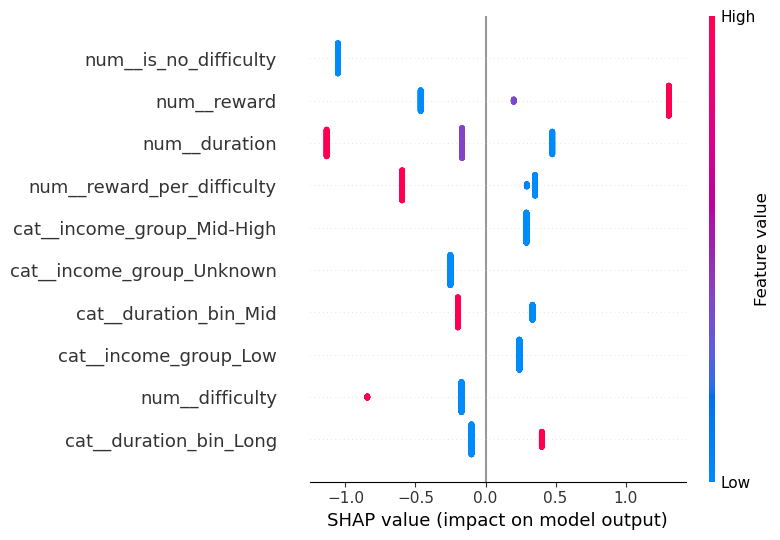

In [ ]:
#SHAP & 변환된 X에 동일 위치 적용

shap.summary_plot(
    shap_values[segment_pos],
    X_test_transformed.iloc[segment_pos],
    max_display=10
)

저소득 X 고난이도 세그먼트의 이탈은
보상이 작거나 정보가 부족해서가 아니라,
“조건 없는 오퍼 + 장기 구조 + 체감 가치 불균형”이
동시에 작동하며 발생한다.

모델이 찾은 ‘이탈 신호’가
전체 고객의 일반적 패턴인지,
아니면 우리가 정의한 실패 세그먼트에서만 튀는 구조인지 검증하기 위해서다.

🔹 STEP 1. 비교 대상 세그먼트 명확히 정의

🎯 우리가 검증할 실패 세그먼트 2개
	1.	저소득 × 고난이도 오퍼 (조건 설계 실패)
	2.	신규 × 단기 오퍼 (온보딩 실패)

In [ ]:
# ================================
# 실패 세그먼트 플래그 정의
# ================================

df_m = df_m.copy()

# ① 실패 세그먼트 1: 저소득 × 고난이도
df_m["seg_low_income_high_diff"] = (
    (df_m["income_group"] == "Low") &
    (df_m["difficulty"] >= 10)
).astype(int)

# ② 실패 세그먼트 2: 신규 × 단기 오퍼
# 신규 기준: join_year == 가장 최신 연도
latest_year = df_m["join_year"].max()

df_m["seg_new_short"] = (
    (df_m["join_year"] == latest_year) &
    (df_m["duration_bin"] == "Short")
).astype(int)

df_m[["seg_low_income_high_diff", "seg_new_short"]].mean()

seg_low_income_high_diff    0.080106
seg_new_short               0.045060
dtype: float64

🔹 STEP 2. “왜 비교를 하냐면” → 전체 vs 실패 세그먼트

🎯 핵심 질문

“모델이 중요하다고 말한 변수들이
실패 세그먼트에서는 어느 방향으로 얼마나 다른가?”

⸻

📌 셀 2 — SHAP용 데이터 다시 준비 (안정 버전)

In [ ]:
# SHAP에서 인덱스 꼬임 방지용
X_test_reset = X_test.reset_index(drop=True)
shap_values_reset = shap_values[:X_test_reset.shape[0]]

In [ ]:
#실패 세그먼트 1: 저소득 × 고난이도 검증
# 실패 세그먼트 1 인덱스
seg1_idx = (
    (X_test_reset["income_group"] == "Low") &
    (X_test_reset["difficulty"] >= 10)
)

seg1_idx.mean()  # 표본 비율 확인

np.float64(0.07743970692988704)

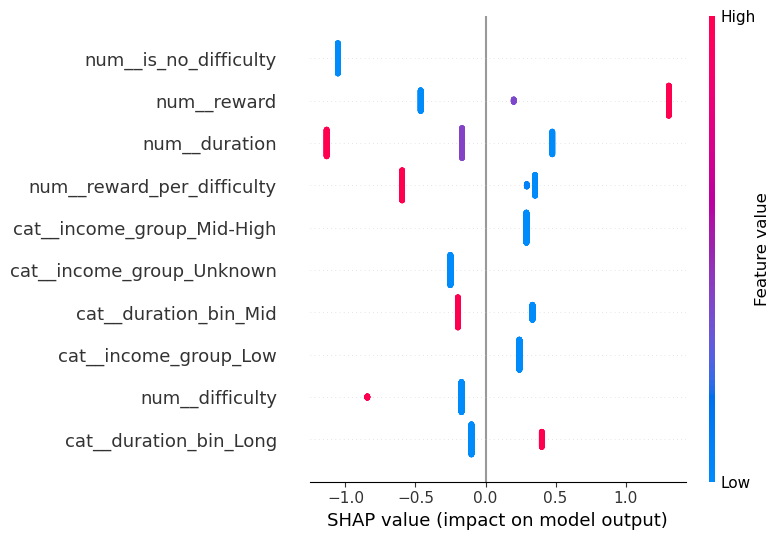

In [ ]:
# SHAP 비교 시각화 
import shap

shap.summary_plot(
    shap_values_reset[seg1_idx],
    X_test_transformed.loc[seg1_idx],
    max_display=10,
    show=True
)

In [ ]:
# X_test에 대응하는 원본 행(df_m) 가져오기
meta_test = df_m.loc[X_test.index, ["join_year", "duration_bin"]].copy()

print(meta_test.shape)
display(meta_test.head())

(9827, 2)


,join_year,duration_bin
41102,2016,Mid
46646,2017,Long
13823,2017,Mid
48699,2018,Mid
6176,2017,Mid


In [ ]:
# 최신 가입연도 = 신규 기준(네 정의대로)
latest_year = df_m["join_year"].max()
print("latest_year:", latest_year)

# 실패 세그먼트2: 신규 × 단기 오퍼
seg2_idx = (
    (meta_test["join_year"] == latest_year) &
    (meta_test["duration_bin"] == "Short")
)

print("seg2 ratio:", seg2_idx.mean().round(4))
print("seg2 count:", seg2_idx.sum())

latest_year: 2018
seg2 ratio: 0.0444
seg2 count: 436


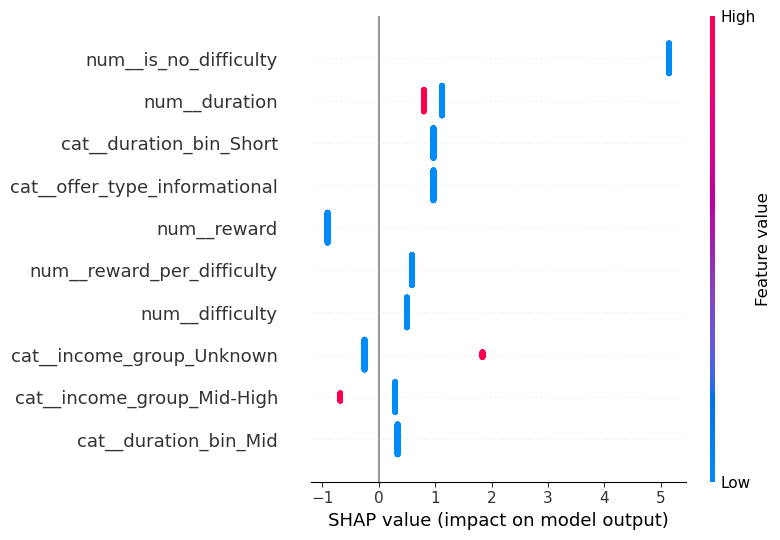

In [ ]:
import numpy as np
import shap

seg2_pos = np.where(seg2_idx.values)[0]  # 위치 index로 변환

shap.summary_plot(
    shap_values[seg2_pos],
    X_test_transformed.iloc[seg2_pos],
    max_display=10
)

2️⃣ 네가 지금 만든 3개 SHAP 그림의 의미 정리

네가 올린 순서 기준으로 설명할게.

(1) 전체 SHAP (맨 마지막에 붙인 것)

👉 이건 모델의 전반적인 평균 판단 기준

예시 해석:
	•	num_is_no_difficulty ↑ → 이탈 확률 크게 증가
	•	num_reward ↑ → 이탈 확률 증가
	•	num_reward_per_difficulty ↓ → 이탈 증가
	•	duration Short → 이탈 증가

즉,

전체적으로 보면
	•	조건 없는 오퍼
	•	보상 대비 조건이 나쁜 오퍼
	•	짧은 기간 오퍼
에서 이탈이 많다

이건 **“보편 법칙”**이야.

⸻

(2) 실패 세그먼트 1 SHAP

저소득 × 고난이도

👉 여기서 보는 포인트는
“전체랑 뭐가 달라졌냐”

눈에 띄는 차이:
	•	num_reward_per_difficulty
	•	전체보다 훨씬 강하게 오른쪽(+)
	•	num_difficulty
	•	이 세그먼트에서는 부정적 영향이 더 큼
	•	소득 관련 변수(income_group_Low)
	•	전체보다 영향력 증가

📌 해석 문장 (바로 써먹기용):

전체 고객 기준에서는 보상이나 난이도가 평균적인 영향 요인이었으나,
저소득 × 고난이도 세그먼트에서는
‘조건 대비 보상’과 ‘난이도 자체’가
이탈을 결정짓는 핵심 요인으로 증폭되어 작동한다.

이게 바로 네가 말한
👉 “할 수 없어서 못 하는 실패”
를 모델이 증명해준 장면이야.

⸻

(3) 실패 세그먼트 2 SHAP

신규 × 단기 오퍼

여기서 핵심은 완전히 달라.

튀는 포인트:
	•	cat_duration_bin_Short
	•	num_duration
	•	informational

👉 소득/보상/난이도는 상대적으로 뒤로 밀림

📌 해석 문장:

신규 고객 × 단기 오퍼 세그먼트에서는
경제적 제약 변수보다
오퍼 지속 기간과 경험 축(duration, informational) 이
이탈을 설명하는 주요 요인으로 작동한다.